Imports & Load Data

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('../data/spotify_tracks.csv')
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (114000, 21)

Data Types:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


Check Nulls & Duplicates 

In [2]:
print("Null Values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null Values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 0


Drop Unnecessary Columns

In [3]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'key', 'mode', 'time_signature', 'explicit'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre']


Feature Distributions

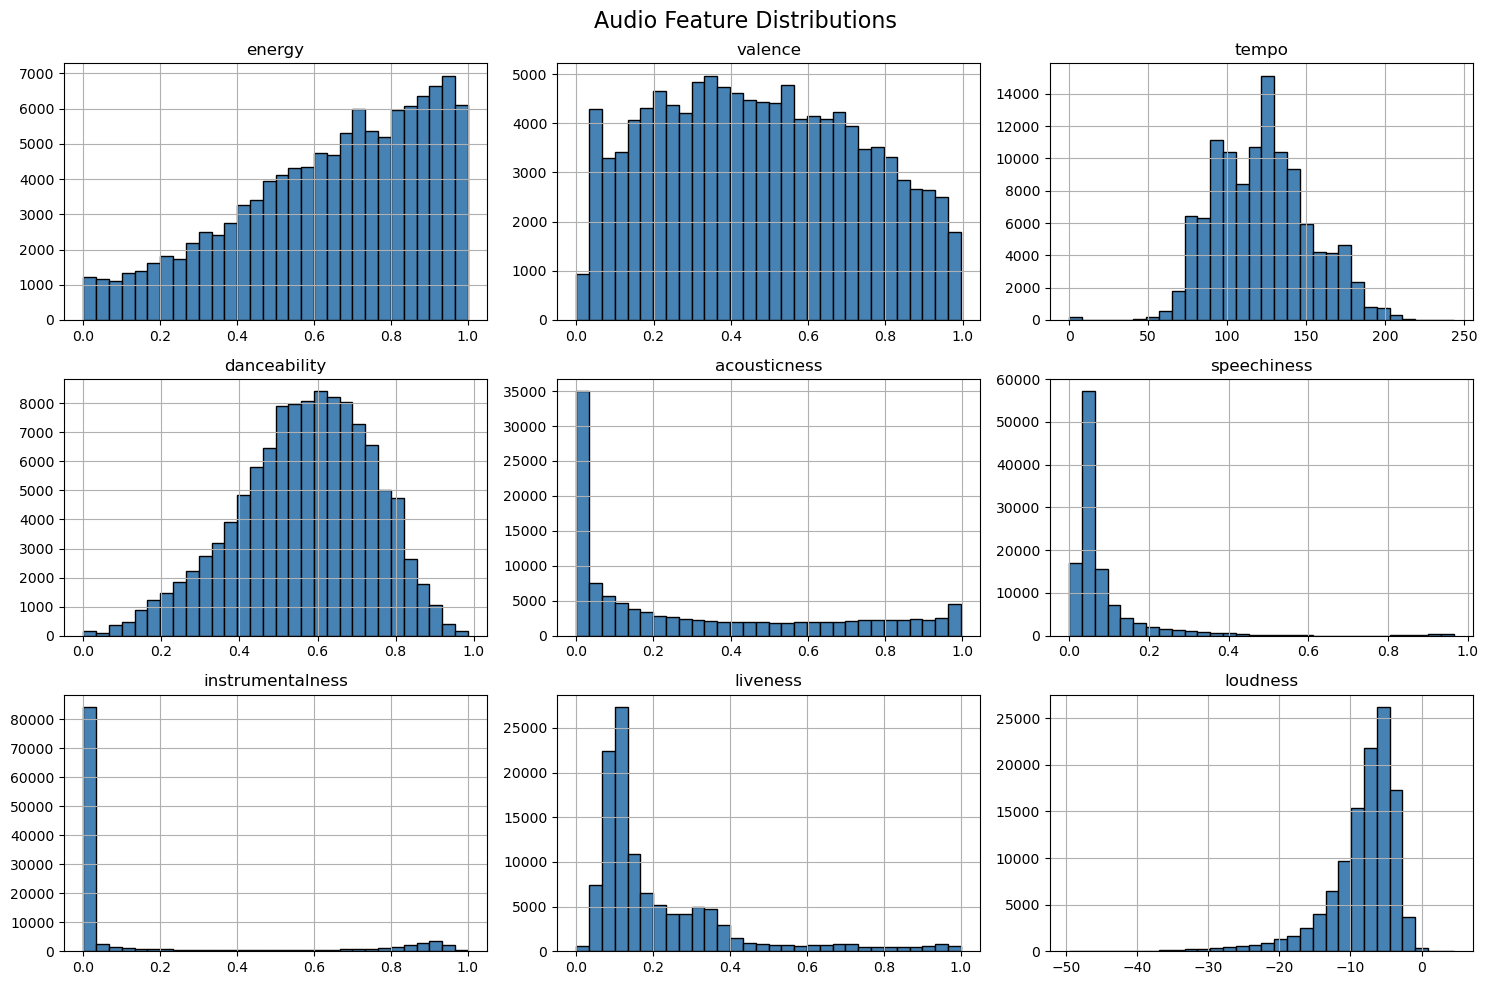

In [4]:
features = ['energy', 'valence', 'tempo', 'danceability', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'loudness']
df[features].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Audio Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

Correlation Heatmap

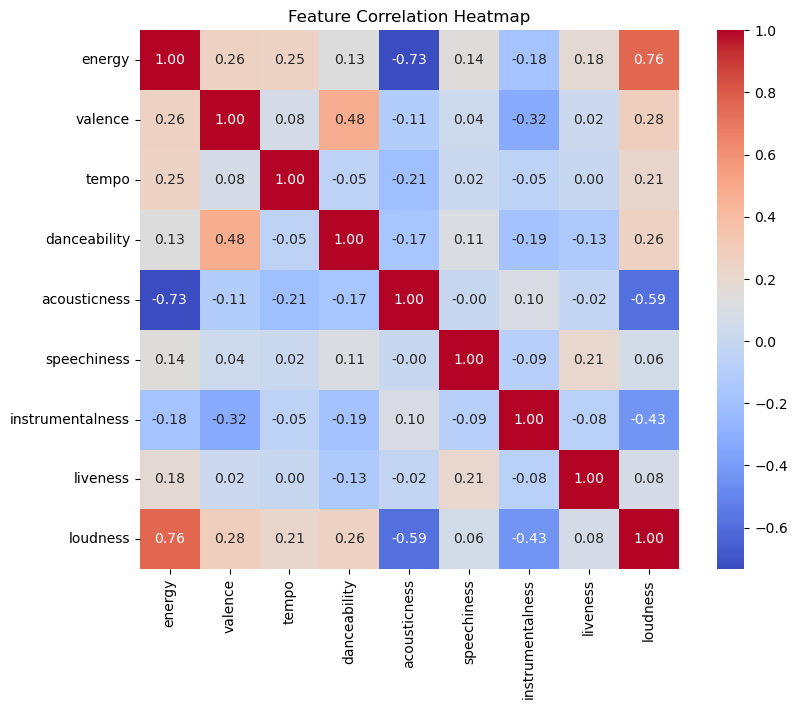

In [5]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

Create Mood Labels

In [6]:
def assign_mood(row):
    if row['valence'] > 0.6 and row['energy'] > 0.5:
        return 'Happy'
    elif row['valence'] < 0.4 and row['energy'] < 0.4:
        return 'Sad'
    elif row['tempo'] > 120 and row['energy'] > 0.7:
        return 'Energetic'
    elif row['acousticness'] > 0.6 and row['energy'] < 0.4:
        return 'Calm'
    else:
        return 'Neutral'

df['mood'] = df.apply(assign_mood, axis=1)
print(df['mood'].value_counts())

mood
Neutral      41523
Happy        32867
Energetic    19917
Sad          14510
Calm          5183
Name: count, dtype: int64


Mood Distribution Plot

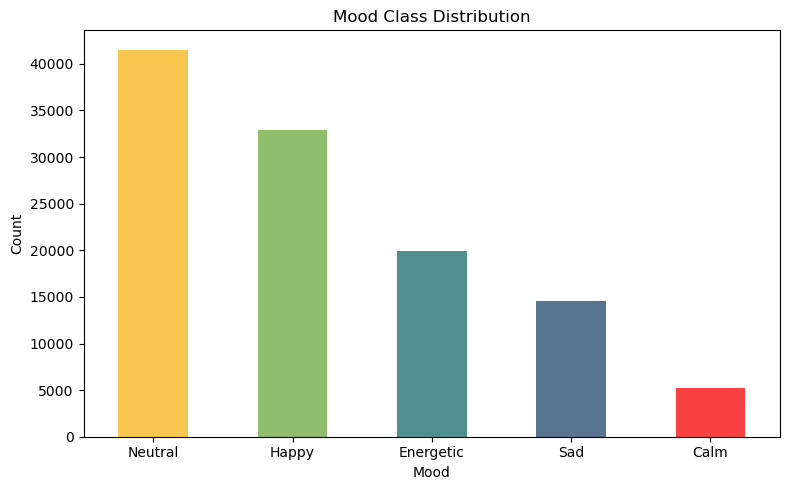

In [7]:
plt.figure(figsize=(8, 5))
df['mood'].value_counts().plot(kind='bar', color=['#f9c74f','#90be6d','#4d908e','#577590','#f94144'])

plt.title('Mood Class Distribution')
plt.xlabel('Mood')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Valence vs Energy Scatter (Visual Proof of Mood Clusters)

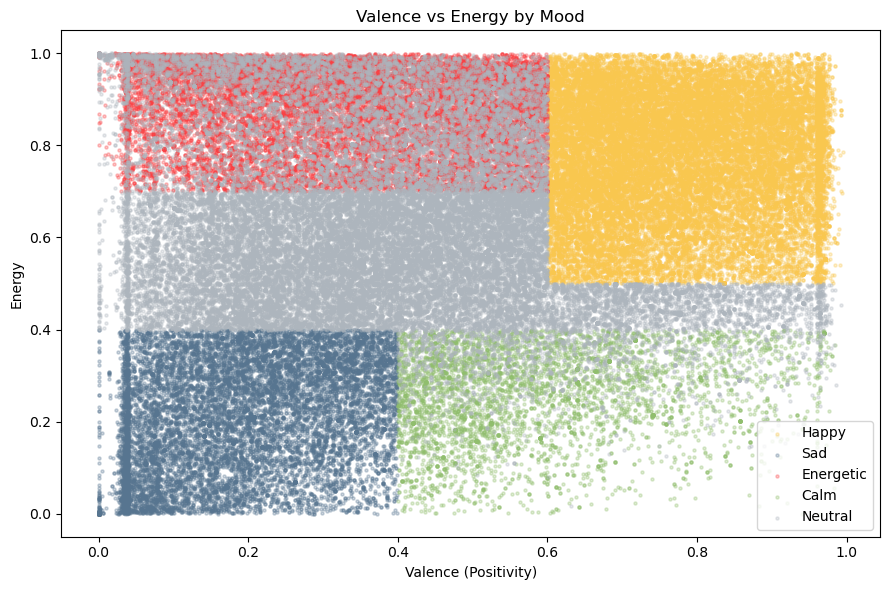

In [8]:
plt.figure(figsize=(9, 6))
colors = {'Happy': '#f9c74f', 'Sad':'#577590', 'Energetic':'#f94144', 'Calm':'#90be6d', 'Neutral':'#adb5bd'}

for mood, color in colors.items():
    subset = df[df['mood'] == mood]
    plt.scatter(subset['valence'], subset['energy'], label=mood, alpha=0.3, s=5, color=color)

plt.xlabel('Valence (Positivity)')
plt.ylabel('Energy')
plt.title('Valence vs Energy by Mood')
plt.legend()
plt.tight_layout()
plt.show()